## Time Series Forecasting 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv("store_sales.csv")

In [3]:
df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   object 
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 285.3+ KB


In [5]:
df.describe()


,store,sales,promo,holiday
count,7300.000000,7300.000000,7300.000000,7300.000000
mean,5.500000,228.434571,0.202192,0.104110
std,2.872478,26.625636,0.401662,0.305424
min,1.000000,160.710000,0.000000,0.000000
25%,3.000000,209.217500,0.000000,0.000000
50%,5.500000,226.795000,0.000000,0.000000
75%,8.000000,245.590000,0.000000,0.000000
max,10.000000,340.730000,1.000000,1.000000


In [6]:
df.isnull().sum()

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df['day_of_week'] = df['date'].dt.dayofweek

df['month'] = df['date'].dt.month

df['weekend_flag'] = df['day_of_week'].isin([5,6]).astype(int)

df['year'] = df['date'].dt.year

In [9]:
daily_sales = df.groupby('date')['sales'].sum().reset_index()

daily_sales = daily_sales.set_index('date')

daily_sales.head()

,sales
date,
2022-01-01,1947.47
2022-01-02,1942.29
2022-01-03,2099.73
2022-01-04,2292.64
2022-01-05,2274.62


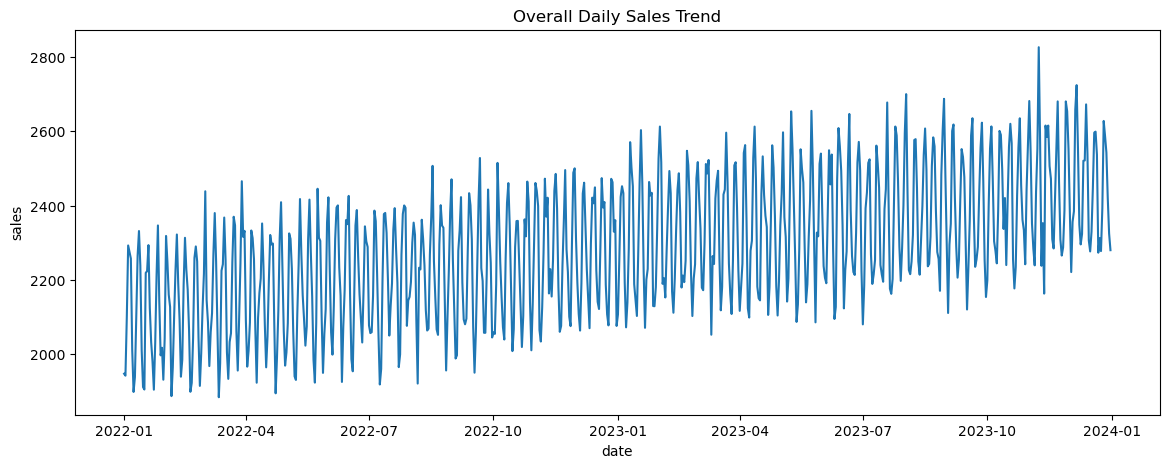

In [10]:
plt.figure(figsize=(14,5))

plt.plot(daily_sales.index, daily_sales['sales'])

plt.title("Overall Daily Sales Trend")

plt.xlabel("date")

plt.ylabel("sales")

plt.show()

1. trend (does it increase over time)
2. seasonality (repeated yearly pattern)
3. noise (randomness)
### THIS IS NOT STATIONARY

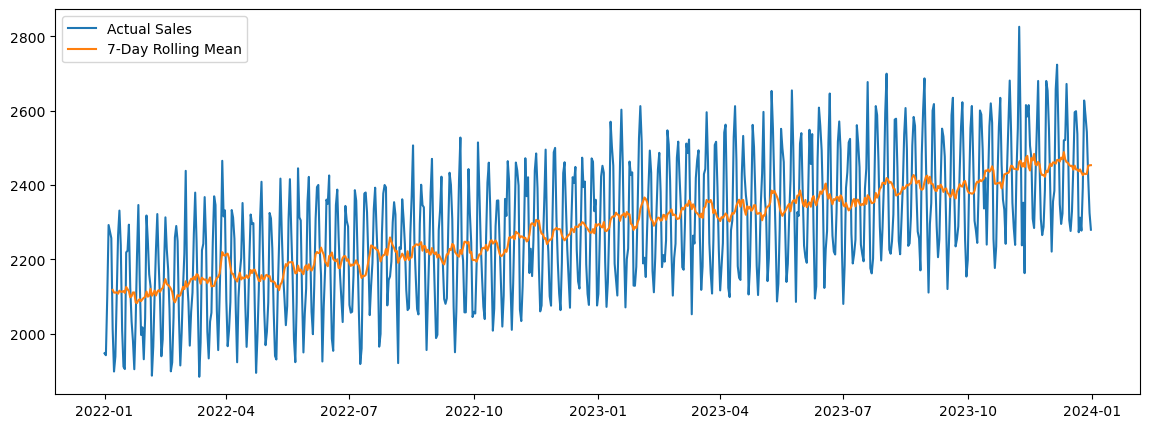

In [11]:
daily_sales['rolling_mean'] = daily_sales['sales'].rolling(window=7).mean()

plt.figure(figsize=(14,5))

plt.plot(daily_sales['sales'], label='Actual Sales')

plt.plot(daily_sales['rolling_mean'], label='7-Day Rolling Mean')

plt.legend()

plt.show()

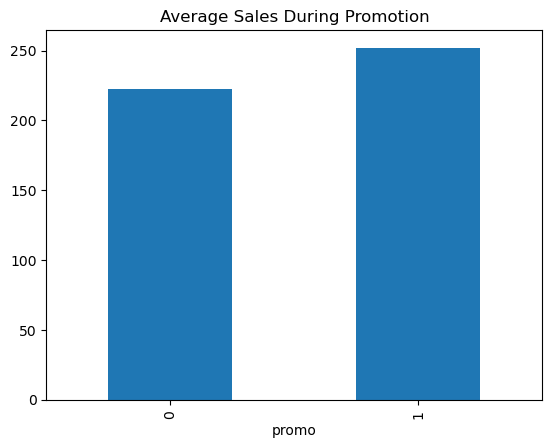

In [12]:
promotion_sales = df.groupby('promo')['sales'].mean()

promotion_sales.plot(kind='bar')

plt.title("Average Sales During Promotion")

plt.show()

Sales are higher during promotional periods, indicating promotions positively impact customer demand.

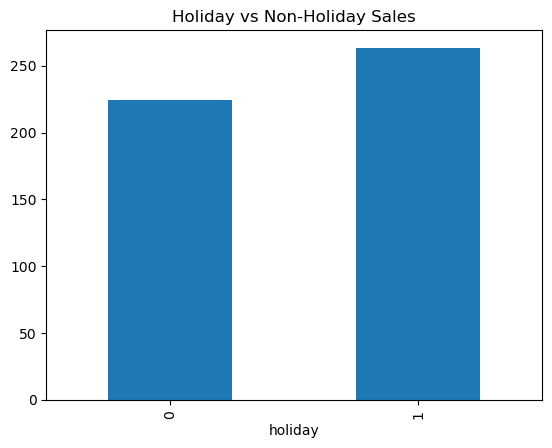

In [13]:
holiday_sales = df.groupby('holiday')['sales'].mean()

holiday_sales.plot(kind='bar')

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

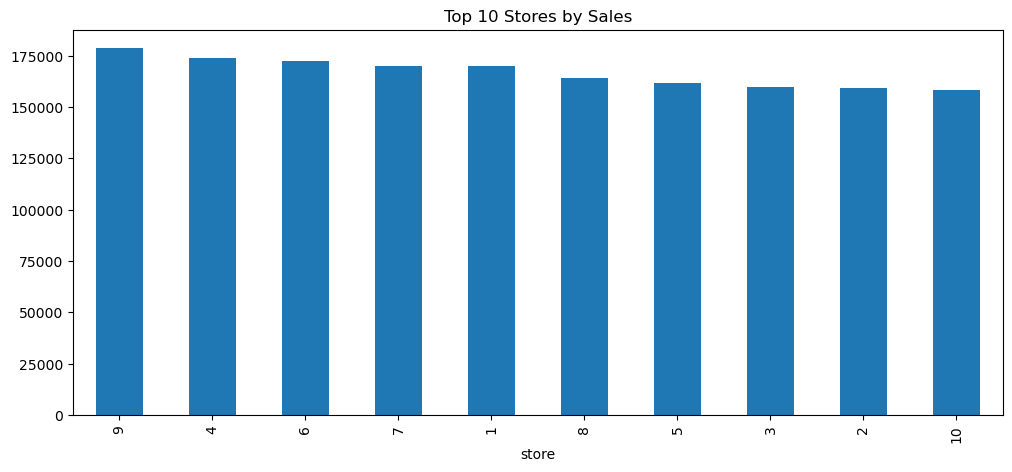

In [14]:
store_sales = df.groupby('store')['sales'].sum().sort_values(ascending=False)

store_sales.head(10).plot(kind='bar', figsize=(12,5))

plt.title("Top 10 Stores by Sales")

plt.show()

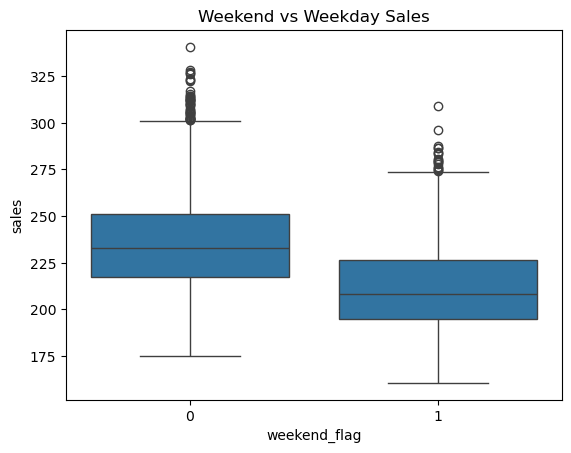

In [15]:
sns.boxplot(x='weekend_flag', y='sales', data=df)

plt.title("Weekend vs Weekday Sales")

plt.show()

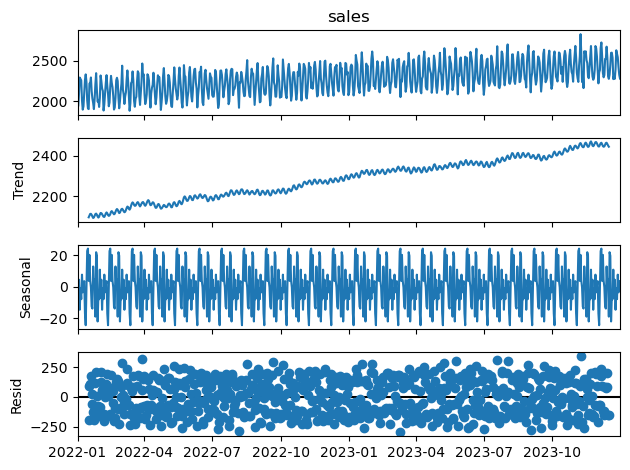

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_sales['sales'],
    model='additive',
    period=30
)

decomposition.plot()

plt.show()

In [17]:
result = adfuller(daily_sales['sales'])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -0.8028529366637839
p-value: 0.8182826022600194


Your series is not stationary.

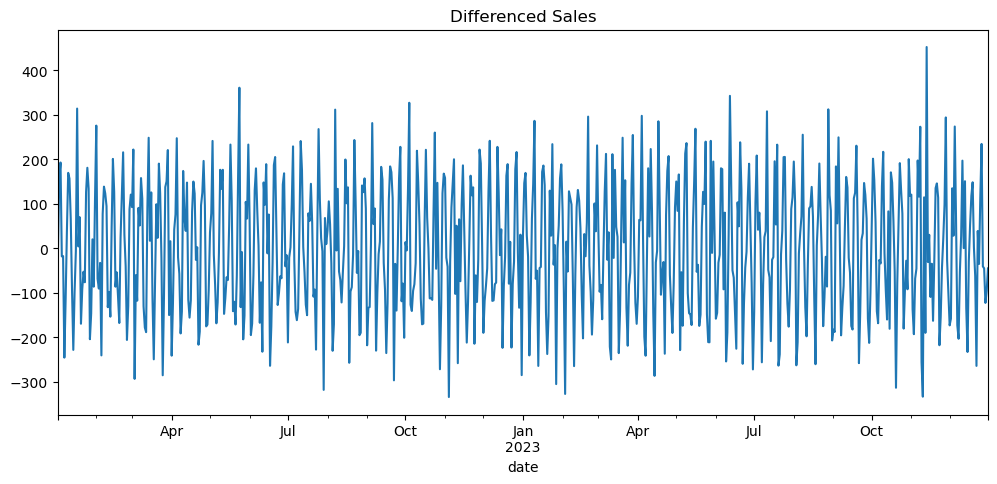

In [18]:
daily_sales['Sales_diff'] = daily_sales['sales'].diff()

daily_sales['Sales_diff'].dropna().plot(figsize=(12,5))

plt.title("Differenced Sales")

plt.show()

In [19]:
result = adfuller(daily_sales['Sales_diff'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -12.614627876653062
p-value: 1.6270199318277835e-23


In [20]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales['sales'][:train_size]

test = daily_sales['sales'][train_size:]

In [21]:
model_arima = ARIMA(train, order=(5,1,2))

model_fit = model_arima.fit()

arima_pred = model_fit.forecast(steps=len(test))

C:\Users\ANAMIKA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ANAMIKA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ANAMIKA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ANAMIKA\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ANAMIKA\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conve

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [23]:
arima_mae = mean_absolute_error(test, arima_pred)

arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

print("ARIMA MAE:", arima_mae)

print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 73.65386148818496
ARIMA RMSE: 95.54417680596679


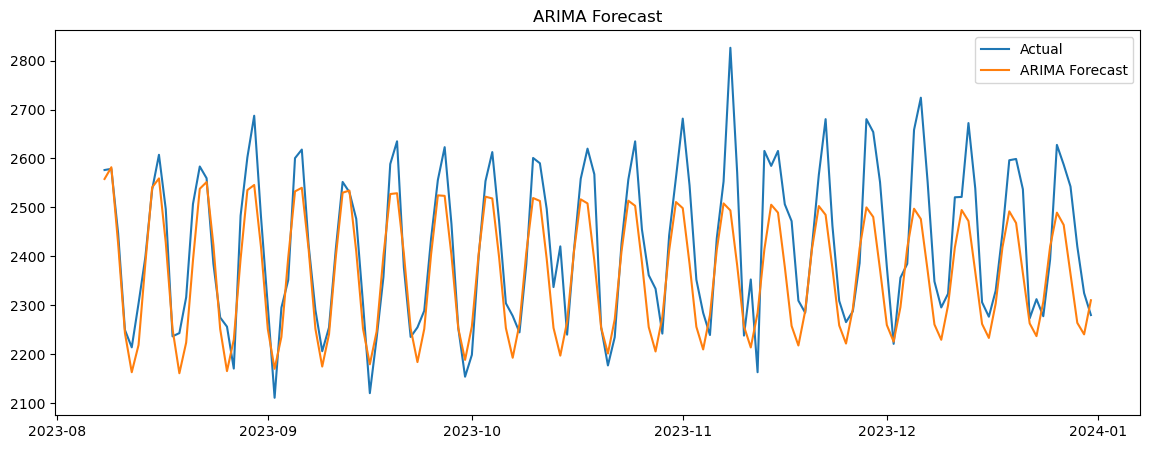

In [24]:
plt.figure(figsize=(14,5))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, arima_pred, label='ARIMA Forecast')

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

In [25]:
!pip install prophet

In [30]:
from prophet import Prophet

prophet_df = daily_sales.reset_index()

print(prophet_df.columns)
print(prophet_df.head())

Index(['date', 'sales', 'rolling_mean', 'Sales_diff'], dtype='object')
        date    sales  rolling_mean  Sales_diff
0 2022-01-01  1947.47           NaN         NaN
1 2022-01-02  1942.29           NaN       -5.18
2 2022-01-03  2099.73           NaN      157.44
3 2022-01-04  2292.64           NaN      192.91
4 2022-01-05  2274.62           NaN      -18.02


In [31]:
prophet_df = daily_sales.reset_index()[['date', 'sales']]

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2022-01-01,1947.47
1,2022-01-02,1942.29
2,2022-01-03,2099.73
3,2022-01-04,2292.64
4,2022-01-05,2274.62


In [32]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(prophet_df)

17:28:30 - cmdstanpy - INFO - Chain [1] start processing
17:28:30 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model_prophet.fit(train_prophet)

17:28:48 - cmdstanpy - INFO - Chain [1] start processing
17:28:48 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = model_prophet.make_future_dataframe(periods=len(test_prophet))

forecast = model_prophet.predict(future)

prophet_pred = forecast.iloc[train_size:]['yhat']

In [35]:
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred)

prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))

print("Prophet MAE:", prophet_mae)

print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 44.95298335906664
Prophet RMSE: 59.020151510830225


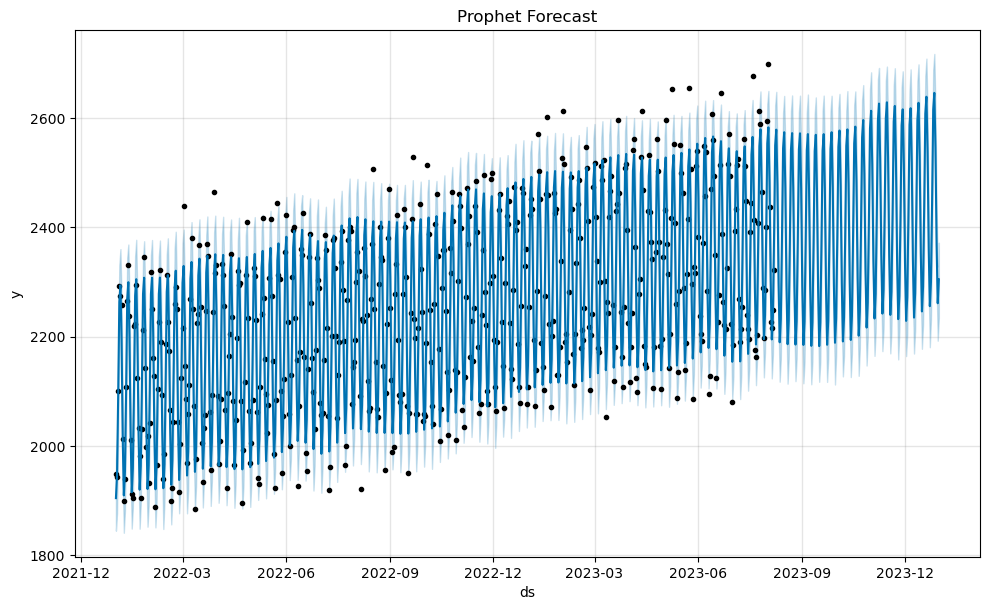

In [36]:
model_prophet.plot(forecast)

plt.title("Prophet Forecast")

plt.show()

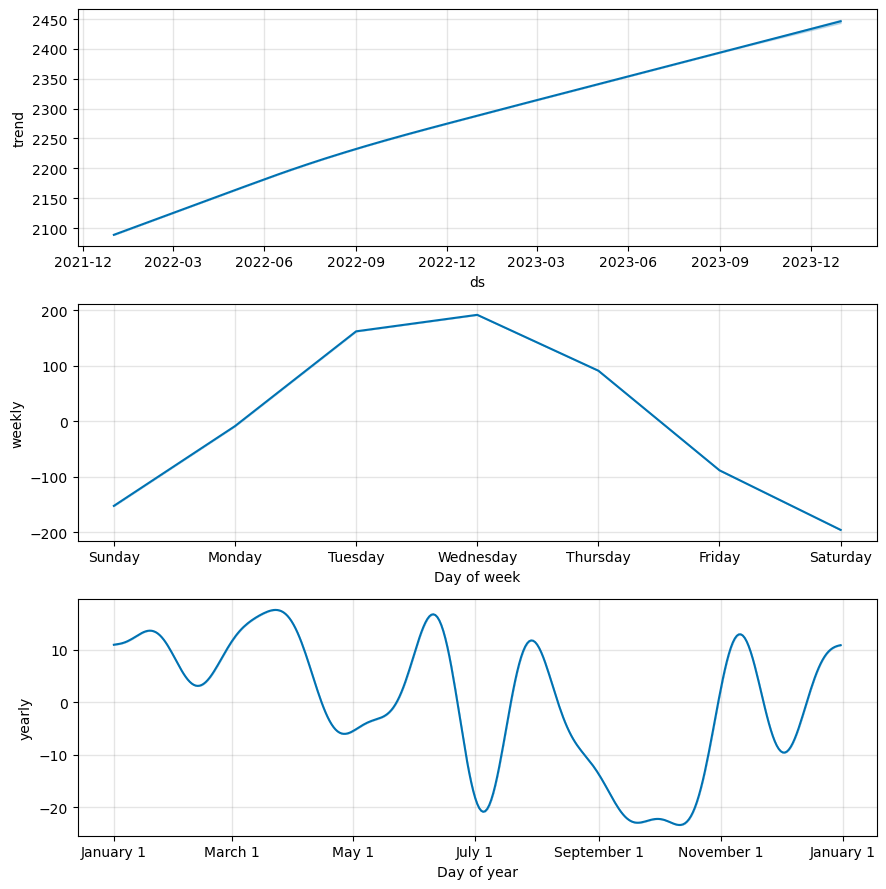

In [37]:
model_prophet.plot_components(forecast)

plt.show()

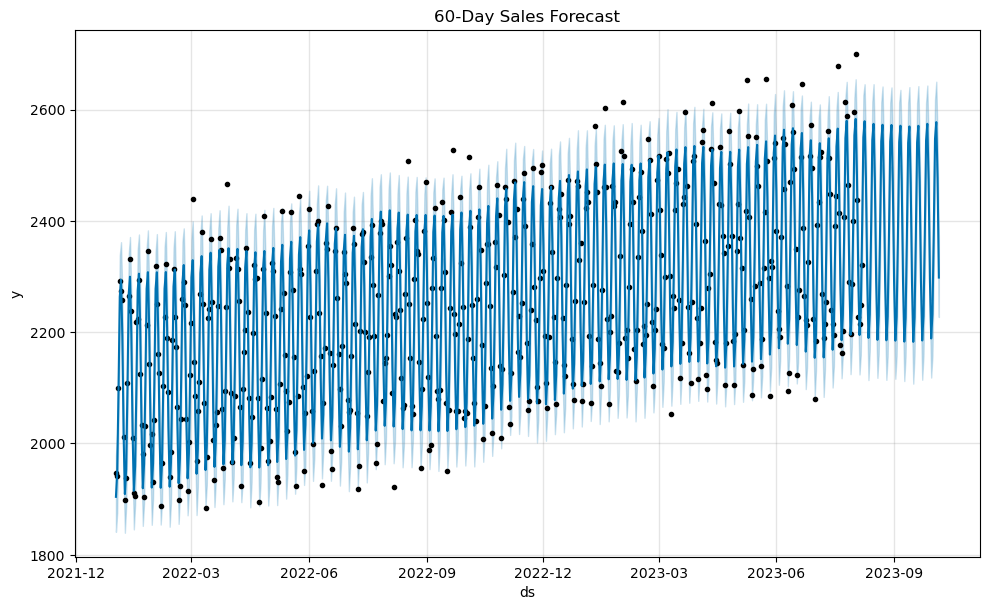

In [38]:
future_60 = model_prophet.make_future_dataframe(periods=60)

forecast_60 = model_prophet.predict(future_60)

model_prophet.plot(forecast_60)

plt.title("60-Day Sales Forecast")

plt.show()

In [39]:
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'MAE': [arima_mae, prophet_mae],
    'RMSE': [arima_rmse, prophet_rmse]
})

comparison

,Model,MAE,RMSE
0,ARIMA,73.653861,95.544177
1,Prophet,44.952983,59.020152


## Business Insights

Mid-week periods generate the highest revenue, indicating stronger customer activity during these days. Sales are seasonal and repeat similar patterns annually, making forecasting useful for long-term inventory planning. Demand spikes occur periodically and should be anticipated to avoid stock shortages.
### Recommendataion
- Increase stock before high-demand mid-week periods (Tuesday–Wednesday).

- Increase inventory during forecasted seasonal peaks.

- Maintain safety stock during high-uncertainty demand periods.

### Promotions
- Run promotions during low-sales periods such as Friday and Saturday

- Use promotions before seasonal dips to maintain stable revenue

- Schedule promotions strategically before expected demand spikes